Data Cleaning

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("../data/sales.csv")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
df.shape

(9800, 18)

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)


In [13]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [14]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [15]:
df["Year"] = df["Order Date"].dt.year

In [16]:
df["Month"] = df["Order Date"].dt.month

In [17]:
df["Month Name"] = df["Order Date"].dt.strftime("%B")

In [18]:
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [19]:
df[[
    "Order Date",
    "Year",
    "Month",
    "Month Name",
    "Year-Month"
]].head()

,Order Date,Year,Month,Month Name,Year-Month
0,2017-11-08,2017,11,November,2017-11
1,2017-11-08,2017,11,November,2017-11
2,2017-06-12,2017,6,June,2017-06
3,2016-10-11,2016,10,October,2016-10
4,2016-10-11,2016,10,October,2016-10


In [20]:
df["Sales"].dtype

dtype('float64')

In [21]:
df["Sales"].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [22]:
(df["Sales"] <= 0).sum()

np.int64(0)

In [23]:
df["Sales"].isnull().sum()

np.int64(0)

In [24]:
df.nlargest(10, "Sales")[[
    "Order ID",
    "Customer Name",
    "Product Name",
    "Sales"
]]

,Order ID,Customer Name,Product Name,Sales
2697,CA-2015-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,22638.480
6826,CA-2017-118689,Tamara Chand,Canon imageCLASS 2200 Advanced Copier,17499.950
8153,CA-2018-140151,Raymond Buch,Canon imageCLASS 2200 Advanced Copier,13999.960
2623,CA-2018-127180,Tom Ashbrook,Canon imageCLASS 2200 Advanced Copier,11199.968
4190,CA-2018-166709,Hunter Lopez,Canon imageCLASS 2200 Advanced Copier,10499.970
9039,CA-2017-117121,Adrian Barton,GBC Ibimaster 500 Manual ProClick Binding System,9892.740
4098,CA-2015-116904,Sanjit Chand,Ibico EPK-21 Electric Binding System,9449.950
4277,US-2017-107440,Bill Shonely,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930
8488,CA-2017-158841,Sanjit Engle,HP Designjet T520 Inkjet Large Format Printer ...,8749.950
6425,CA-2017-143714,Christopher Conant,Canon imageCLASS 2200 Advanced Copier,8399.976


In [25]:
print("Categories:")
print(df["Category"].unique())

print("\nSub-Categories:")
print(df["Sub-Category"].unique())

print("\nRegions:")
print(df["Region"].unique())

print("\nSegments:")
print(df["Segment"].unique())

print("\nShip Modes:")
print(df["Ship Mode"].unique())

Categories:
<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Sub-Categories:
<StringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str

Regions:
<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

Segments:
<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

Ship Modes:
<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str


In [26]:
print("Unique Orders:", df["Order ID"].nunique())
print("Unique Customers:", df["Customer ID"].nunique())
print("Unique Products:", df["Product ID"].nunique())

Unique Orders: 4922
Unique Customers: 793
Unique Products: 1861


In [27]:
df["Sales"].describe()
(df["Sales"] <= 0).sum()
df["Sales"].isnull().sum()

np.int64(0)

In [ ]:
df["Sales"].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [29]:
df["Sales"].dtype

dtype('float64')

In [30]:
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country",
    "Region",
    "Category",
    "Sub-Category"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].unique())
    


--- Ship Mode ---
<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

--- Segment ---
<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

--- Country ---
<StringArray>
['United States']
Length: 1, dtype: str

--- Region ---
<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

--- Category ---
<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

--- Sub-Category ---
<StringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str


In [31]:
df[categorical_columns].isnull().sum()

Ship Mode       0
Segment         0
Country         0
Region          0
Category        0
Sub-Category    0
dtype: int64

In [32]:
print("Unique Orders:", df["Order ID"].nunique())
print("Unique Customers:", df["Customer ID"].nunique())
print("Unique Products:", df["Product ID"].nunique())

Unique Orders: 4922
Unique Customers: 793
Unique Products: 1861


In [33]:
df[col].unique()


<StringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str

In [35]:
df[df["Postal Code"].isnull()][
    ["City", "State", "Postal Code"]
]


,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


In [36]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (9800, 22)

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Year-Month        0
dtype: int64

Duplicate rows: 0

Data types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str


In [37]:
df.to_csv("../data/sales_cleaned.csv", index=False)

* Exploratory Data Analysis


In [38]:
total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
median_sales = df["Sales"].median()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_products = df["Product ID"].nunique()

print("Total Sales:", total_sales)
print("Average Sales per Row:", average_sales)
print("Median Sales:", median_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Sales: 2261536.7827
Average Sales per Row: 230.76905945918367
Median Sales: 54.489999999999995
Total Orders: 4922
Total Customers: 793
Total Products: 1861


In [39]:
yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
    .sort_index()
)

print(yearly_sales)

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


In [40]:
yearly_growth = yearly_sales.pct_change() * 100

print(yearly_growth)

Year
2015          NaN
2016    -4.255484
2017    30.636812
2018    20.303396
Name: Sales, dtype: float64


In [41]:
monthly_sales = (
    df.groupby("Year-Month")["Sales"]
    .sum()
    .sort_index()
)

monthly_sales.head(12)


Year-Month
2015-01    14205.7070
2015-02     4519.8920
2015-03    55205.7970
2015-04    27906.8550
2015-05    23644.3030
2015-06    34322.9356
2015-07    33781.5430
2015-08    27117.5365
2015-09    81623.5268
2015-10    31453.3930
2015-11    77907.6607
2015-12    68167.0585
Name: Sales, dtype: float64

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Year-Month'>

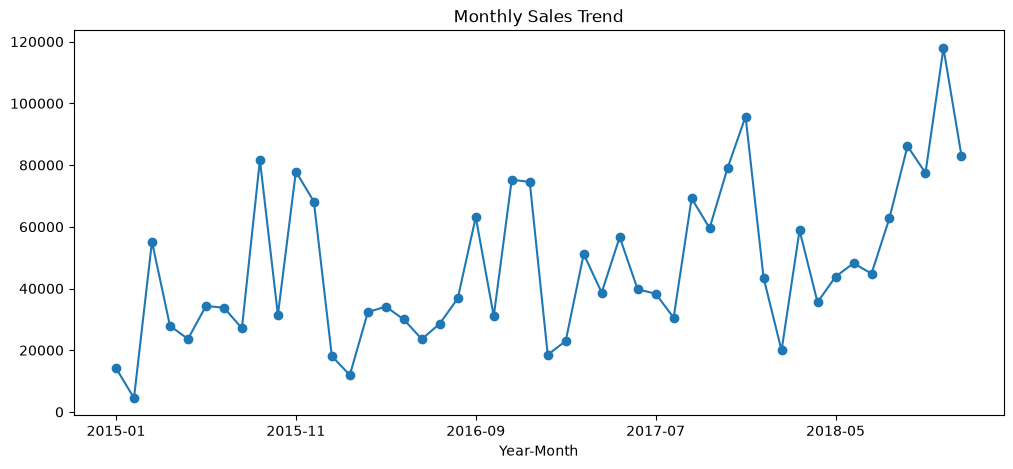

In [42]:
monthly_sales.plot(
    figsize=(12, 5),
    marker="o",
    title="Monthly Sales Trend"
)

Insight : 
Sales declined slightly in 2016 but recovered strongly in 2017 and continued growing in 2018, with 2018 recording the highest annual sales.

In [46]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [47]:
category_percentage = (
    category_sales / category_sales.sum() * 100
).round(2)

print(category_percentage)

Category
Technology         36.59
Furniture          32.22
Office Supplies    31.19
Name: Sales, dtype: float64


<Axes: title={'center': 'Sales by Category'}, xlabel='Category'>

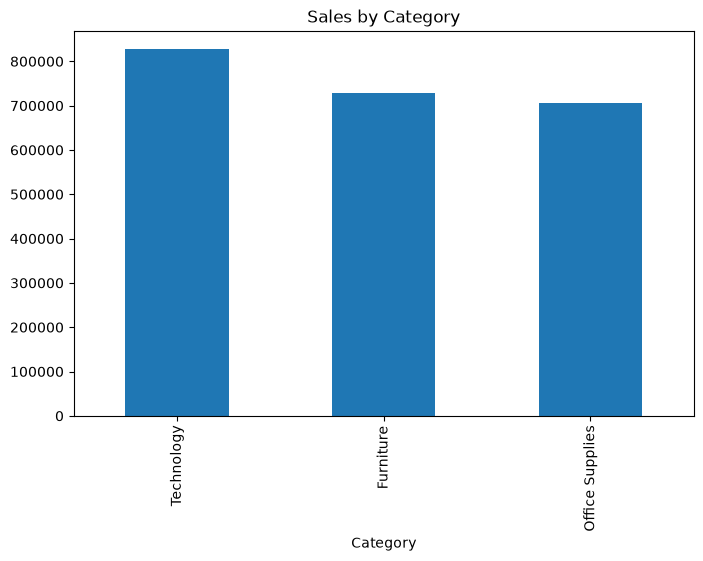

In [48]:
category_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Sales by Category"
)


In [49]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(subcategory_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


<Axes: title={'center': 'Sales by Sub-Category'}, xlabel='Sub-Category'>

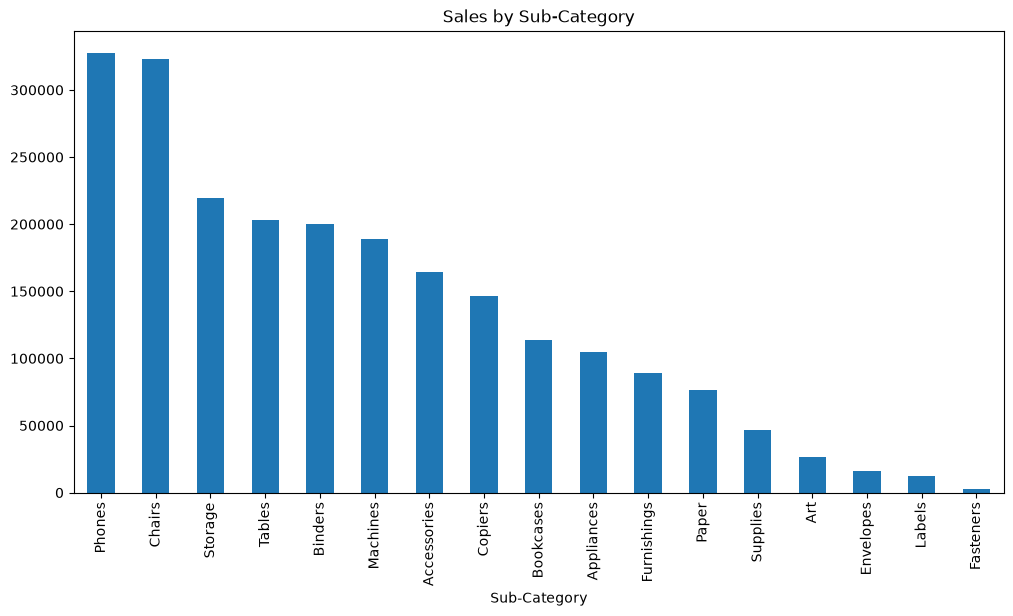

In [50]:

subcategory_sales.plot(
    kind="bar",
    figsize=(12, 6),
    title="Sales by Sub-Category"
)

Insight 
* Phones and Chairs are clearly the strongest sub-categories.
* Phones and Chairs are the strongest sub-categories, generating roughly $328K and $323K respectively, while Fasteners, Labels, and Envelopes contribute relatively little sales.


In [51]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [52]:
region_percentage = (
    region_sales / region_sales.sum() * 100
).round(2)

print(region_percentage)

Region
West       31.40
East       29.60
Central    21.78
South      17.21
Name: Sales, dtype: float64


<Axes: title={'center': 'Sales by Region'}, xlabel='Region'>

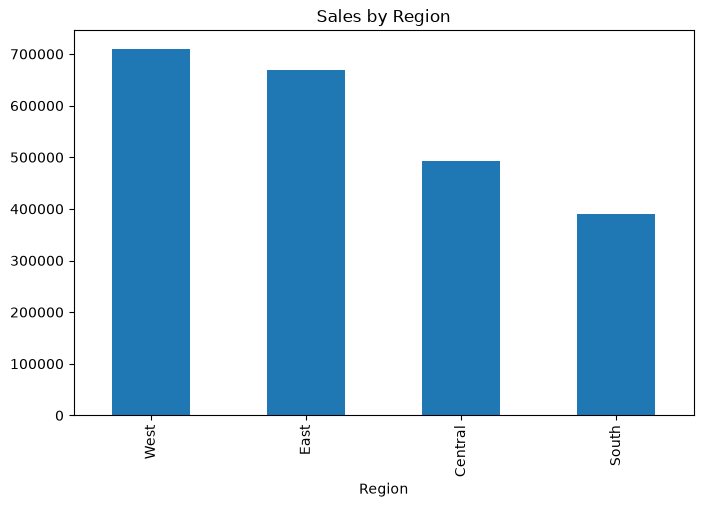

In [53]:
region_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Sales by Region"
)


In [54]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


In [55]:
segment_percentage = (
    segment_sales / segment_sales.sum() * 100
).round(2)

print(segment_percentage)

Segment
Consumer       50.76
Corporate      30.44
Home Office    18.79
Name: Sales, dtype: float64


<Axes: title={'center': 'Sales by Customer Segment'}, xlabel='Segment'>

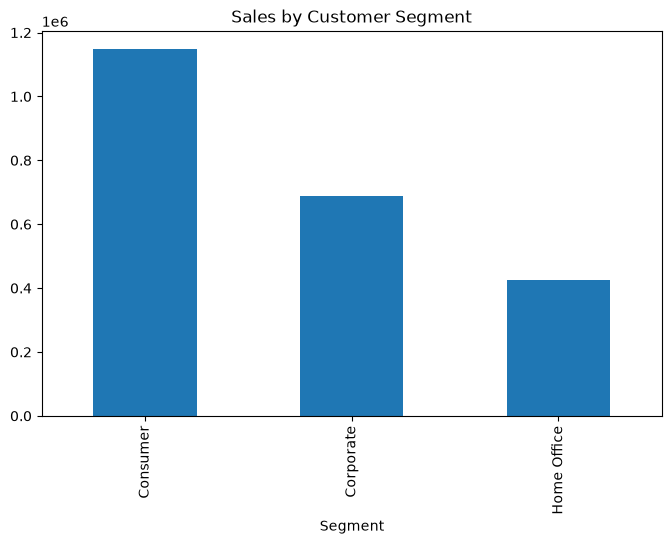

In [56]:
segment_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Sales by Customer Segment"
)

In [57]:
ship_sales = (
    df.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(ship_sales)

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64


In [58]:
ship_percentage = (
    ship_sales / ship_sales.sum() * 100
).round(2)

print(ship_percentage)

Ship Mode
Standard Class    59.29
Second Class      19.89
First Class       15.28
Same Day           5.54
Name: Sales, dtype: float64


<Axes: title={'center': 'Sales by Shipping Mode'}, xlabel='Ship Mode'>

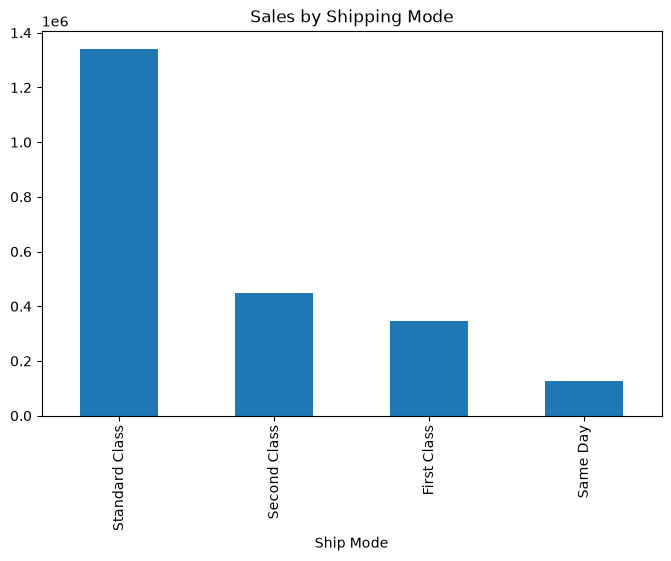

In [59]:
ship_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Sales by Shipping Mode"
)

In [60]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


<Axes: title={'center': 'Top 10 Products by Sales'}, ylabel='Product Name'>

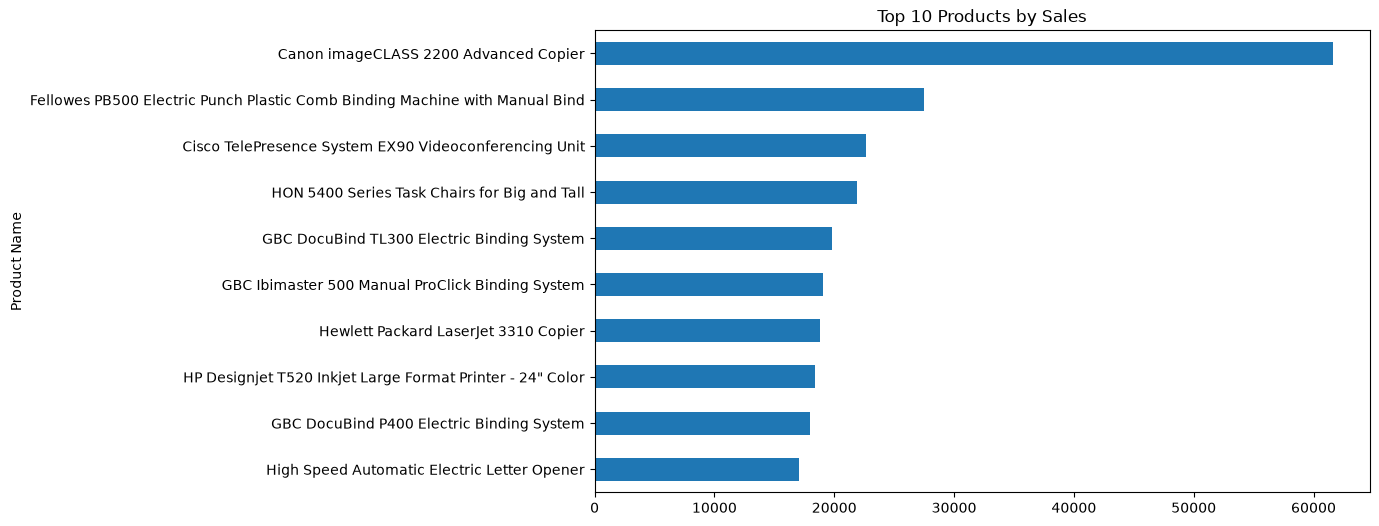

In [61]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Products by Sales"
)

In [62]:
top_10_percentage = (
    top_products.sum() / df["Sales"].sum() * 100
)

print("Top 10 Products Sales Share:", round(top_10_percentage, 2), "%")

Top 10 Products Sales Share: 10.82 %


In [63]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


<Axes: title={'center': 'Top 10 Customers by Sales'}, ylabel='Customer Name'>

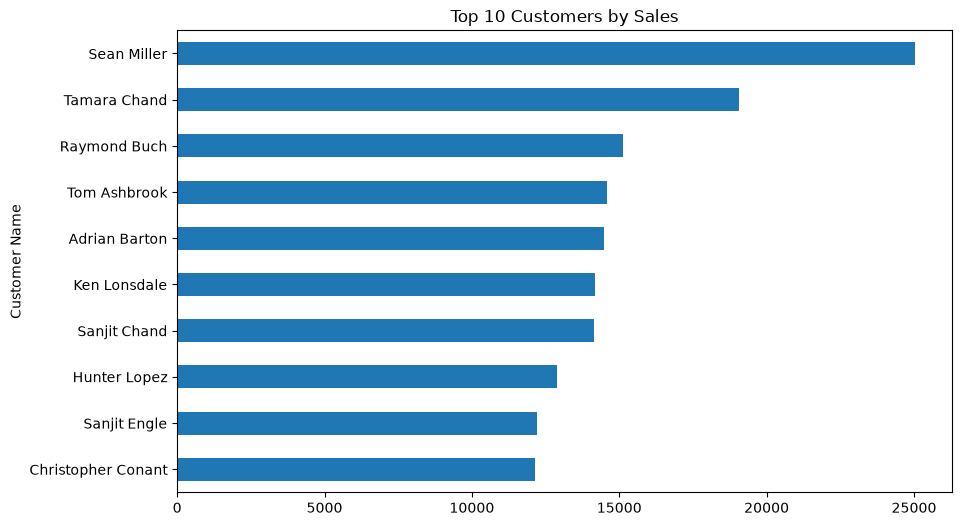

In [64]:
top_customers.sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Customers by Sales"
)

In [65]:
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(state_sales.head(10))


State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


In [66]:
print(state_sales.tail(10))

State
New Mexico              4783.522
Iowa                    4443.560
Idaho                   4382.486
Kansas                  2914.310
District of Columbia    2865.020
Wyoming                 1603.136
South Dakota            1315.560
Maine                   1270.530
West Virginia           1209.824
North Dakota             919.910
Name: Sales, dtype: float64


<Axes: title={'center': 'Top 10 States by Sales'}, ylabel='State'>

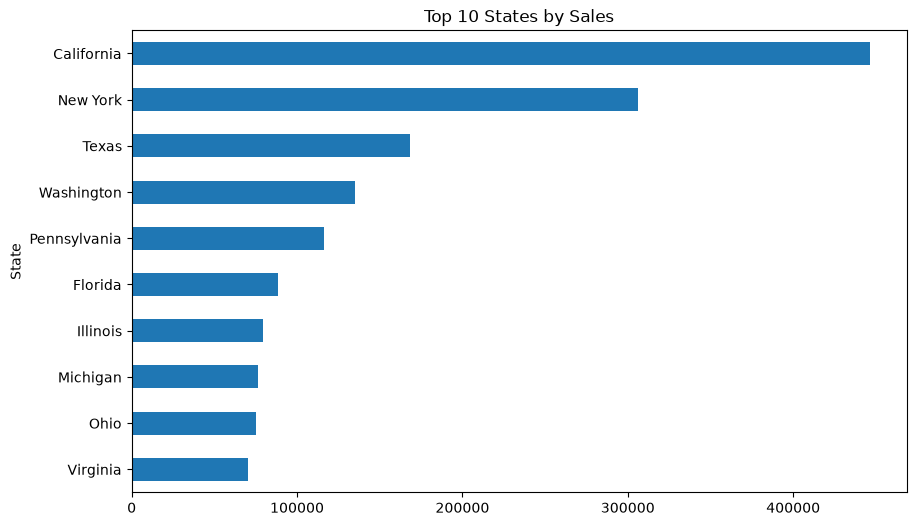

In [67]:
state_sales.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 States by Sales"
)

In [68]:
avg_sales_segment = (
    df.groupby("Segment")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_segment)

Segment
Home Office    243.403309
Corporate      233.150720
Consumer       225.065777
Name: Sales, dtype: float64


In [69]:
avg_sales_category = (
    df.groupby("Category")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_category)

Category
Technology         456.401474
Furniture          350.653790
Office Supplies    119.381001
Name: Sales, dtype: float64


In [71]:
avg_sales_region = (
    df.groupby("Region")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_region)

Region
South      243.524067
East       240.401697
West       226.184613
Central    216.357889
Name: Sales, dtype: float64


In [72]:
monthly_avg = (
    df.groupby("Month Name")["Sales"]
    .mean()
    .reindex([
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ])
)

print(monthly_avg)

Month Name
January      257.627403
February     199.902745
March        290.549393
April        207.432269
May          212.533412
June         211.052856
July         208.802997
August       227.007110
September    221.642106
October      246.596162
November     241.657496
December     232.619515
Name: Sales, dtype: float64


<Axes: title={'center': 'Average Sales by Month'}, xlabel='Month Name'>

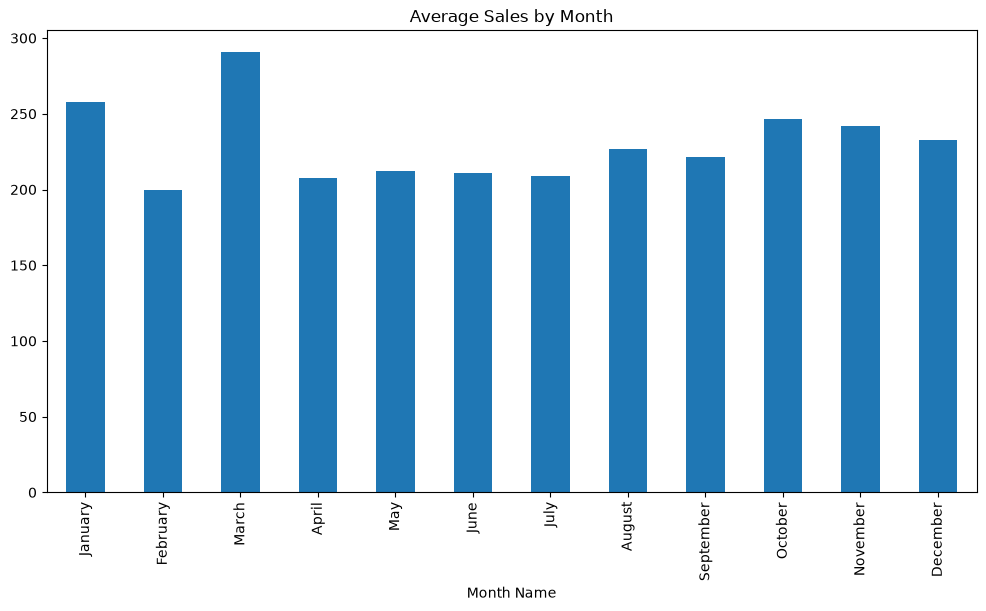

In [73]:
monthly_avg.plot(
    kind="bar",
    figsize=(12, 6),
    title="Average Sales by Month"
)